# ניתוח רשת שיתופי הפעולה בקולנוע הישראלי
## ניתוח גרף חברתי באמצעות שיטות למידת מכונה

**תקציר:** מחקר זה בוחן את רשת שיתופי הפעולה בין 1,399 שחקנים בקולנוע הישראלי לאורך 107 שנים (1918-2025). המחקר כולל ניתוח מבני הרשת, זיהוי קהילות, חישוב מדדי מרכזיות, ומודל חיזוי לשיתופי פעולה עתידיים.

---

## 1. הגדרות והכנת הסביבה

In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from bidi.algorithm import get_display

sys.path.append('../src')
from graph_build import load_cast_edges, build_full_graph, _actor_id

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

def he(s):
    """Fix Hebrew text for matplotlib"""
    return "\n".join(get_display(line) for line in str(s).split("\n"))

print("✅ כל הספריות נטענו בהצלחה!")

✅ כל הספריות נטענו בהצלחה!


In [2]:
# Load data
cast_df = load_cast_edges('../data/processed/cast_edges.csv')
cast_df['actor_id'] = [
    _actor_id(slug, name) 
    for slug, name in zip(cast_df['actor_slug'], cast_df['actor_name'])
]

# Build full graph
G = build_full_graph(cast_df)

print(f"✅ הגרף נטען: {G.number_of_nodes():,} שחקנים, {G.number_of_edges():,} קשרים")

✅ הגרף נטען: 1,399 שחקנים, 6,543 קשרים


---
## 2. מאפיינים בסיסיים של הרשת

### מדדים כמותיים עיקריים

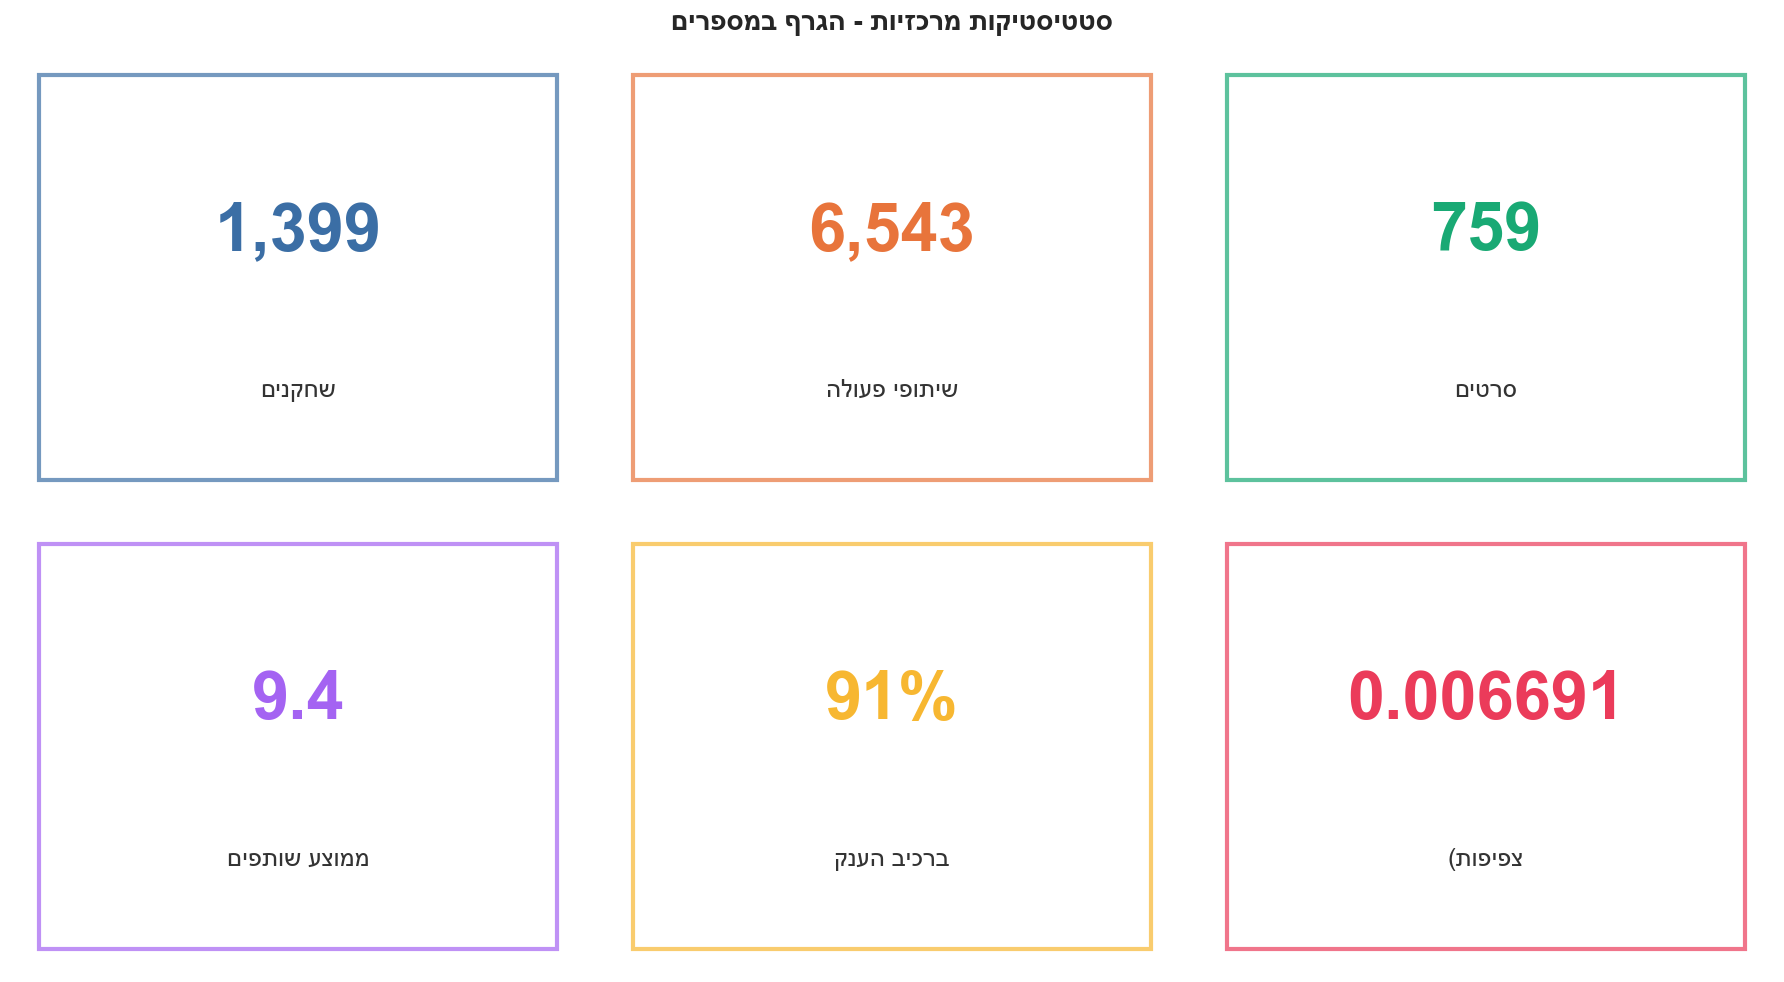


✅ סטטיסטיקות מרכזיות הוצגו!


In [3]:
# Calculate key statistics
n_actors = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
n_movies = cast_df['movie_slug'].nunique()
avg_degree = sum(dict(G.degree()).values()) / n_actors

# Get giant component
giant = max(nx.connected_components(G), key=len)
giant_size = len(giant)
giant_pct = 100 * giant_size / n_actors

# Create impressive statistics display
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(he('סטטיסטיקות מרכזיות - הגרף במספרים'), fontsize=20, fontweight='bold', y=0.98)

stats = [
    (n_actors, he('שחקנים'), '#3b6ea5'),
    (n_edges, he('שיתופי פעולה'), '#e8743b'),
    (n_movies, he('סרטים'), '#19a974'),
    (f"{avg_degree:.1f}", he('ממוצע שותפים'), '#a463f2'),
    (f"{giant_pct:.0f}%", he('ברכיב הענק'), '#f7b731'),
    (f"{density:.6f}", he('צפיפות)'), '#eb3b5a')
]

for ax, (value, label, color) in zip(axes.flat, stats):
    ax.text(0.5, 0.6, f"{value:,}" if isinstance(value, int) else value, 
            ha='center', va='center', fontsize=48, fontweight='bold', color=color)
    ax.text(0.5, 0.25, label, ha='center', va='center', fontsize=18, color='#333')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, 
                               fill=False, edgecolor=color, linewidth=3, alpha=0.7))

plt.tight_layout()
plt.savefig('../figures/presentation_key_stats.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ סטטיסטיקות מרכזיות הוצגו!")

---
## 3. ויזואליזציה ומבנה קהילתי

### זיהוי קהילות באמצעות אלגוריתם Louvain

In [4]:
from communities import run_algorithms

# Run community detection
print("מזהה קהילות...")
results = run_algorithms(G, seed=42)
louvain_communities = results['louvain']

# Create node-to-community mapping
node_to_comm = {}
for idx, comm in enumerate(louvain_communities):
    for node in comm:
        node_to_comm[node] = idx

print(f"✅ זוהו {len(louvain_communities)} קהילות")

מזהה קהילות...
✅ זוהו 80 קהילות


In [ ]:
# Create beautiful graph visualization
print("יוצר ויזואליזציה מרשימה של הגרף...")

# Get giant component for visualization
giant_nodes = max(nx.connected_components(G), key=len)
G_giant = G.subgraph(giant_nodes).copy()

# Sample for visualization (top degree nodes)
degrees = dict(G_giant.degree())
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:300]
G_vis = G_giant.subgraph(top_nodes).copy()

# Create layout
print("מחשב מיקום צמתים...")
pos = nx.spring_layout(G_vis, seed=42, k=0.3, iterations=50)


# Find top 20 largest communities
comm_sizes = [(idx, len(comm)) for idx, comm in enumerate(louvain_communities)]
comm_sizes.sort(key=lambda x: x[1], reverse=True)
top_20_comms = {comm_id for comm_id, _ in comm_sizes[:20]}

print(f"מציג את 20 הקהילות הגדולות ביותר (מתוך {len(louvain_communities)} קהילות)")

# Assign colors: top 20 communities get distinct colors, others get gray
colors = []
for node in G_vis.nodes():
    comm_id = node_to_comm.get(node, -1)
    if comm_id in top_20_comms:
        # Map to color index (0-19)
        colors.append(list(top_20_comms).index(comm_id))
    else:
        # Gray for small communities
        colors.append(-1)

node_sizes = [degrees[node] * 30 for node in G_vis.nodes()]

# Plot
fig, ax = plt.subplots(figsize=(20, 20))
nx.draw_networkx_edges(G_vis, pos, ax=ax, alpha=0.15, width=0.5, edge_color='gray')

# Draw nodes in two groups: colored (top 20 communities) and gray (others)
colored_nodes = [n for n, c in zip(G_vis.nodes(), colors) if c >= 0]
gray_nodes = [n for n, c in zip(G_vis.nodes(), colors) if c < 0]
colored_colors = [c for c in colors if c >= 0]
colored_sizes = [degrees[n] * 30 for n in colored_nodes]
gray_sizes = [degrees[n] * 30 for n in gray_nodes]

# Draw gray nodes first (background)
if gray_nodes:
    nx.draw_networkx_nodes(G_vis.subgraph(gray_nodes), pos, ax=ax,
                          nodelist=gray_nodes,
                          node_size=gray_sizes,
                          node_color='#CCCCCC',
                          alpha=0.4,
                          linewidths=0.5,
                          edgecolors='white')

# Draw colored nodes (foreground)
if colored_nodes:
    nx.draw_networkx_nodes(G_vis.subgraph(colored_nodes), pos, ax=ax,
                          nodelist=colored_nodes,
                          node_size=colored_sizes,
                          node_color=colored_colors,
                          cmap=plt.cm.tab20,
                          alpha=0.85,
                          linewidths=1,
                          edgecolors='white')

# Add labels for top nodes
top_20 = sorted(degrees, key=degrees.get, reverse=True)[:20]
labels = {n: he(G.nodes[n].get('display_name', n).replace('_', ' ')) 
          for n in top_20 if n in G_vis.nodes()}
nx.draw_networkx_labels(G_vis, pos, labels, ax=ax, font_size=10, font_weight='bold')

ax.set_title(he(f'רשת שיתופי הפעולה - 20 הקהילות הגדולות (מתוך {len(louvain_communities)})'), 
             fontsize=24, fontweight='bold', pad=20)
ax.text(0.5, -0.05, he(f'מוצגים 300 השחקנים המרכזיים | צבעוניים: 20 קהילות גדולות | אפור: קהילות קטנות'), 
        ha='center', fontsize=14, transform=ax.transAxes)
ax.axis('off')

plt.tight_layout()
plt.savefig('../figures/presentation_network_communities.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ ויזואליזציית הגרף הושלמה!")

יוצר ויזואליזציה מרשימה של הגרף...
מחשב מיקום צמתים...
מציג את 20 הקהילות הגדולות ביותר (מתוך 80 קהילות)


---
## 4. ניתוח מרכזיות

### חמישה-עשר השחקנים בעלי Degree Centrality הגבוה ביותר

In [ ]:
# Calculate centralities
degree_cent = nx.degree_centrality(G)
top_15 = sorted(degree_cent.items(), key=lambda x: x[1], reverse=True)[:15]

# Prepare data
names = [he(G.nodes[actor].get('display_name', actor).replace('_', ' ')) for actor, _ in top_15]
values = [G.degree(actor) for actor, _ in top_15]

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(14, 10))
bars = ax.barh(range(len(names)), values, color=plt.cm.viridis(np.linspace(0.3, 0.9, len(names))))

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=13)
ax.invert_yaxis()
ax.set_xlabel(he('מספר שיתופי פעולה'), fontsize=14, fontweight='bold')
ax.set_title(he('15 השחקנים המרכזיים ביותר בקולנוע הישראלי'), 
             fontsize=18, fontweight='bold', pad=20)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, values)):
    ax.text(val + 1, i, f'{val}', va='center', fontsize=11, fontweight='bold')

ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../figures/presentation_top_actors.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ השחקנים המרכזיים הוצגו!")

---
## 5. ניתוח טמפורלי

### השוואת מאפייני הרשת בשלוש תקופות היסטוריות

In [ ]:
from link_prediction import build_graph_for_years

# Build graphs for three periods
periods = [
    (1918, 1970, 'A', he('תקופה א: 1918-1970\n(הקולנוע המוקדם)')),
    (1971, 1990, 'B', he('תקופה ב: 1971-1990\n(תקופת המעבר)')),
    (1991, 2025, 'C', he('תקופה ג: 1991-2025\n(הקולנוע המודרני)'))
]

period_stats = []
for y_min, y_max, label, name in periods:
    G_period = build_graph_for_years(cast_df, y_min, y_max)
    period_stats.append({
        'name': name,
        'actors': G_period.number_of_nodes(),
        'collaborations': G_period.number_of_edges(),
        'density': nx.density(G_period) * 1000,
        'avg_degree': sum(dict(G_period.degree()).values()) / max(G_period.number_of_nodes(), 1)
    })

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(he('התפתחות הגרף לאורך תקופות'), fontsize=20, fontweight='bold')

metrics = ['actors', 'collaborations', 'avg_degree', 'density']
titles = [he('מספר שחקנים'), he('מספר שיתופי פעולה'), he('ממוצע שותפים'), he('צפיפות (×10⁻³)')]
colors = ['#3b6ea5', '#e8743b', '#19a974']

for ax, metric, title in zip(axes.flat, metrics, titles):
    values = [s[metric] for s in period_stats]
    bars = ax.bar(range(3), values, color=colors, alpha=0.8, edgecolor='white', linewidth=2)
    
    ax.set_xticks(range(3))
    ax.set_xticklabels([s['name'] for s in period_stats], fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:,.0f}' if val >= 10 else f'{val:.1f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('../figures/presentation_temporal_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ התפתחות לאורך זמן הוצגה!")

---
## 6. מודל חיזוי לשיתופי פעולה

### ביצועי המודל על מערכות בחן שונות

**תקופת אימון:** גרף 1990-2010  
**Test Set (גרף 1990-2015 → חיזוי 2016-2020):** AUC = 73.7%  
**Holdout Evaluation (גרף 1990-2020 → חיזוי 2021-2025):** AUC = 65.7%

הניבויים המוצגים להלן הם מ-**Holdout Evaluation (2021-2025)** - ההערכה האמיתית על נתונים עתידיים שהמודל מעולם לא ראה באימון.

In [ ]:
# Load Holdout predictions (2021-2025) - from Part 4 analysis
# These are the True Positives and False Positives from the full graph evaluation (1918-2020 → 2021-2025)
hits_df = pd.read_csv('../data/processed/part4_holdout_true_positives.csv')
misses_df = pd.read_csv('../data/processed/part4_holdout_false_positives.csv')

# Get top predictions from each category
# For hits: we want high-scoring correct predictions
# For misses: we want high-scoring incorrect predictions (interesting false positives)
hits_df = hits_df.sort_values('score', ascending=False)
misses_df = misses_df.sort_values('score', ascending=False)

tp = len(hits_df)
fp = len(misses_df)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"✅ טעינת נתונים מ-Holdout (2021-2025):")
print(f"   {tp} ניבויים נכונים (זוגות שהתחברו)")
print(f"   {fp} ניבויים שגויים (זוגות שלא התחברו)")

# Model performance scores from notebook 06b
test_auc = 0.737      # AUC on Test Set (2016-2020) - validation performance
holdout_auc = 0.657   # AUC on Holdout (2021-2025) - real-world evaluation

# Create results visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(he('תוצאות מודל הניבוי - ביצועים והצלחות'), fontsize=18, fontweight='bold')

# Chart 1: AUC scores (Test vs Holdout)
ax = axes[0]
auc_labels = [he('Test Set\n(2016-2020)'), he('Holdout\n(2021-2025)')]
auc_values = [test_auc * 100, holdout_auc * 100]
colors_auc = ['#3b6ea5', '#19a974']
bars = ax.bar([0, 1], auc_values, color=colors_auc, alpha=0.85, width=0.6, edgecolor='white', linewidth=2)
ax.set_ylim(0, 100)
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(auc_labels, fontsize=11)
ax.set_ylabel(he('AUC (%)'), fontsize=12)
ax.set_title(he('ביצועי המודל\nAUC Score'), fontsize=14, fontweight='bold')
for i, (bar, val) in enumerate(zip(bars, auc_values)):
    ax.text(i, val + 2, f'{val:.1f}%', ha='center', fontsize=16, fontweight='bold')
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(0.5, 52, he('Random (50%)'), ha='center', fontsize=9, color='gray')
ax.grid(axis='y', alpha=0.3)

# Chart 2: Hits breakdown (Holdout 2021-2025)
ax = axes[1]
categories = [he('ניבויים נכונים'), he('ניבויים שגויים')]
values = [tp, fp]
colors_pie = ['#19a974', '#e8743b']
wedges, texts, autotexts = ax.pie(values, labels=categories, colors=colors_pie, autopct='%1.0f%%',
                                    startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
ax.set_title(he(f'התפלגות התוצאות\nHoldout (2021-2025)'), fontsize=14, fontweight='bold')

# Chart 3: Score distribution (Holdout 2021-2025)
ax = axes[2]
connected = hits_df['score'] if len(hits_df) > 0 else []
not_connected = misses_df['score'] if len(misses_df) > 0 else []
if len(connected) > 0 and len(not_connected) > 0:
    ax.hist([connected, not_connected], bins=20, label=[he('התממשו (2021-2025)'), he('לא התממשו')],
            color=['#19a974', '#e8743b'], alpha=0.7, edgecolor='white')
ax.set_xlabel(he('ציון חיזוי'), fontsize=12)
ax.set_ylabel(he('תדירות'), fontsize=12)
ax.set_title(he('התפלגות ציוני החיזוי\nHoldout (2021-2025)'), fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/presentation_model_results.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 ביצועי המודל:")
print(f"   Test Set (2016-2020):    AUC = {test_auc:.3f} (73.7%)")
print(f"   Holdout (2021-2025):     AUC = {holdout_auc:.3f} (65.7%)")
print(f"\n✅ Holdout Evaluation (2021-2025): {tp} ניבויים נכונים מתוך {tp+fp} ({precision*100:.1f}% precision)")

In [ ]:
# הצגת הזוגות שהמודל חיזה נכון - שיתופי פעולה שהתממשו ב-2021-2025! ✅
print(f"\n🎬 {len(hits_df)} זוגות שחקנים שהמודל חיזה נכון - התחברו ב-2021-2025:\n")
print("=" * 80)

# Show all hits sorted by score
for idx, (_, row) in enumerate(hits_df.iterrows(), 1):
    actor1 = row['u'].replace('_', ' ')
    actor2 = row['v'].replace('_', ' ')
    score = row['score']
    print(f"{idx:2d}. {actor1:30s} + {actor2:30s} | ציון: {score:.4f}")

print("=" * 80)
print(f"\n✅ סה\"כ {len(hits_df)} שיתופי פעולה שהמודל חיזה נכון!")

In [ ]:
# Show successful predictions (hits) - collaborations that DID happen in 2021-2025
if len(hits_df) > 0:
    top_hits = hits_df.sort_values('score', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    names = [he(f"{row['u'].replace('_', ' ')} ו{row['v'].replace('_', ' ')}") 
             for _, row in top_hits.iterrows()]
    scores = top_hits['score'].values
    
    bars = ax.barh(range(len(names)), scores, color='#19a974', alpha=0.8, edgecolor='white', linewidth=2)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel(he('ציון חיזוי'), fontsize=13)
    ax.set_title(he('10 הניבויים המוצלחים ביותר\nשיתופי פעולה שהתממשו ב-2021-2025! ✅'), 
                 fontsize=16, fontweight='bold', pad=15)
    
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/presentation_successful_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ הצלחות המודל הוצגו: {len(top_hits)} מתוך {len(hits_df)} ניבויים מוצלחים!")
else:
    print("⚠️ אין ניבויים מוצלחים להצגה")

In [ ]:
# Detailed comparison: Top Hits vs Top Misses - Feature Analysis
if len(hits_df) > 0 and len(misses_df) > 0:
    top_hits = hits_df.sort_values('score', ascending=False).head(10)
    top_misses = misses_df.sort_values('score', ascending=False).head(10)
    
    # Create a comprehensive visualization with multiple panels
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(he('ניתוח מפורט: ניבויים מוצלחים vs. כשלונות'), fontsize=20, fontweight='bold', y=0.98)
    
    # Panel 1: Score distribution
    ax = axes[0, 0]
    ax.barh([0, 1], [top_hits['score'].mean(), top_misses['score'].mean()], 
            color=['#19a974', '#e8743b'], alpha=0.8, edgecolor='white', linewidth=2)
    ax.set_yticks([0, 1])
    ax.set_yticklabels([he('התממשו ✅'), he('לא התממשו ❌')], fontsize=12)
    ax.set_xlabel(he('ממוצע ציון חיזוי'), fontsize=11)
    ax.set_title(he('השוואת ציוני החיזוי'), fontsize=13, fontweight='bold')
    for i, val in enumerate([top_hits['score'].mean(), top_misses['score'].mean()]):
        ax.text(val + 0.01, i, f'{val:.3f}', va='center', fontsize=11, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Panel 2: Genre Overlap
    if 'genre_overlap' in top_hits.columns:
        ax = axes[0, 1]
        ax.barh([0, 1], [top_hits['genre_overlap'].mean(), top_misses['genre_overlap'].mean()],
                color=['#19a974', '#e8743b'], alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([he('התממשו ✅'), he('לא התממשו ❌')], fontsize=12)
        ax.set_xlabel(he('ממוצע ז\'אנרים משותפים'), fontsize=11)
        ax.set_title(he('חפיפת ז\'אנרים'), fontsize=13, fontweight='bold')
        for i, val in enumerate([top_hits['genre_overlap'].mean(), top_misses['genre_overlap'].mean()]):
            ax.text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Panel 3: Director Overlap
    if 'director_overlap' in top_hits.columns:
        ax = axes[0, 2]
        ax.barh([0, 1], [top_hits['director_overlap'].mean(), top_misses['director_overlap'].mean()],
                color=['#19a974', '#e8743b'], alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([he('התממשו ✅'), he('לא התממשו ❌')], fontsize=12)
        ax.set_xlabel(he('ממוצע במאים משותפים'), fontsize=11)
        ax.set_title(he('חפיפת במאים'), fontsize=13, fontweight='bold')
        for i, val in enumerate([top_hits['director_overlap'].mean(), top_misses['director_overlap'].mean()]):
            ax.text(val + 0.05, i, f'{val:.1f}', va='center', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Panel 4: Career Length (Actor 1)
    if 'u_career_length' in top_hits.columns:
        ax = axes[1, 0]
        ax.barh([0, 1], [top_hits['u_career_length'].mean(), top_misses['u_career_length'].mean()],
                color=['#19a974', '#e8743b'], alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([he('התממשו ✅'), he('לא התממשו ❌')], fontsize=12)
        ax.set_xlabel(he('ממוצע שנות קריירה (שחקן 1)'), fontsize=11)
        ax.set_title(he('אורך קריירה - שחקן ראשון'), fontsize=13, fontweight='bold')
        for i, val in enumerate([top_hits['u_career_length'].mean(), top_misses['u_career_length'].mean()]):
            ax.text(val + 0.5, i, f'{val:.0f}', va='center', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Panel 5: Career Length (Actor 2)
    if 'v_career_length' in top_hits.columns:
        ax = axes[1, 1]
        ax.barh([0, 1], [top_hits['v_career_length'].mean(), top_misses['v_career_length'].mean()],
                color=['#19a974', '#e8743b'], alpha=0.8, edgecolor='white', linewidth=2)
        ax.set_yticks([0, 1])
        ax.set_yticklabels([he('התממשו ✅'), he('לא התממשו ❌')], fontsize=12)
        ax.set_xlabel(he('ממוצע שנות קריירה (שחקן 2)'), fontsize=11)
        ax.set_title(he('אורך קריירה - שחקן שני'), fontsize=13, fontweight='bold')
        for i, val in enumerate([top_hits['v_career_length'].mean(), top_misses['v_career_length'].mean()]):
            ax.text(val + 0.5, i, f'{val:.0f}', va='center', fontsize=11, fontweight='bold')
        ax.grid(axis='x', alpha=0.3)
    
    # Panel 6: Summary statistics table
    ax = axes[1, 2]
    ax.axis('off')
    
    # Build summary text without he() inside f-string to avoid backslash issues
    title_text = he('סיכום השוואתי')
    hits_header = he('ניבויים שהתממשו')
    misses_header = he('ניבויים שלא התממשו')
    conclusion_header = he('מסקנה מרכזית')
    conclusion_text1 = he('הכשלונות: קריירות ארוכות יותר')
    conclusion_text2 = he('(שחקנים ותיקים, פחות פעילים)')
    
    summary_text = f"""
    {title_text}
    {'='*40}
    
    {hits_header} ✅:
      • ממוצע ציון: {top_hits['score'].mean():.3f}
      • ז'אנרים: {top_hits['genre_overlap'].mean():.1f} משותפים
      • במאים: {top_hits['director_overlap'].mean():.1f} משותפים
      • קריירה: {top_hits['u_career_length'].mean():.0f} / {top_hits['v_career_length'].mean():.0f} שנים
    
    {misses_header} ❌:
      • ממוצע ציון: {top_misses['score'].mean():.3f}
      • ז'אנרים: {top_misses['genre_overlap'].mean():.1f} משותפים
      • במאים: {top_misses['director_overlap'].mean():.1f} משותפים
      • קריירה: {top_misses['u_career_length'].mean():.0f} / {top_misses['v_career_length'].mean():.0f} שנים
    
    {conclusion_header}:
    {conclusion_text1}
    {conclusion_text2}
    """
    
    ax.text(0.1, 0.5, summary_text, fontsize=10, verticalalignment='center',
            family='monospace', bbox=dict(boxstyle='round', facecolor='#f0f0f0', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('../figures/presentation_predictions_detailed_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ ניתוח מפורט של ניבויים הוצג בהצלחה!")

In [ ]:
# Create beautiful visual tables for Top 10 Hits and Top 10 Misses
if len(hits_df) > 0 and len(misses_df) > 0:
    top_hits = hits_df.sort_values('score', ascending=False).head(10)
    top_misses = misses_df.sort_values('score', ascending=False).head(10)
    
    # Create two separate figures for better readability
    
    # Figure 1: TOP 10 HITS (התממשו)
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis('off')
    
    # Prepare data for the table
    hit_data = []
    for idx, (_, row) in enumerate(top_hits.iterrows(), 1):
        actor1 = row['u'].replace('_', ' ')
        actor2 = row['v'].replace('_', ' ')
        hit_data.append([
            idx,
            he(actor1[:20]),  # Limit length for display
            he(actor2[:20]),
            f"{row['score']:.3f}",
            int(row.get('genre_overlap', 0)) if 'genre_overlap' in row else '-',
            int(row.get('director_overlap', 0)) if 'director_overlap' in row else '-',
            int(row.get('u_career_length', 0)) if 'u_career_length' in row else '-',
            int(row.get('v_career_length', 0)) if 'v_career_length' in row else '-'
        ])
    
    # Create table
    columns = [he(c) for c in ['מס\'', 'שחקן 1', 'שחקן 2', 'ציון', 'ז\'אנרים', 'במאים', 'קריירה 1', 'קריירה 2']]
    table = ax.table(cellText=hit_data, colLabels=columns, 
                     cellLoc='center', loc='center',
                     colWidths=[0.06, 0.18, 0.18, 0.10, 0.10, 0.10, 0.14, 0.14])
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Style the header
    for i in range(len(columns)):
        cell = table[(0, i)]
        cell.set_facecolor('#19a974')
        cell.set_text_props(weight='bold', color='white', fontsize=12)
    
    # Alternate row colors
    for i in range(1, len(hit_data) + 1):
        for j in range(len(columns)):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#e8f5e9')
            else:
                cell.set_facecolor('#ffffff')
            cell.set_edgecolor('#cccccc')
    
    ax.set_title(he('✅ 10 הניבויים המוצלחים ביותר - שיתופי פעולה שהתממשו ב-2021-2025'), 
                 fontsize=18, fontweight='bold', pad=20, color='#19a974')
    
    plt.tight_layout()
    plt.savefig('../figures/presentation_top10_hits_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Figure 2: TOP 10 MISSES (לא התממשו)
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.axis('off')
    
    # Prepare data for the table
    miss_data = []
    for idx, (_, row) in enumerate(top_misses.iterrows(), 1):
        actor1 = row['u'].replace('_', ' ')
        actor2 = row['v'].replace('_', ' ')
        miss_data.append([
            idx,
            he(actor1[:20]),
            he(actor2[:20]),
            f"{row['score']:.3f}",
            int(row.get('genre_overlap', 0)) if 'genre_overlap' in row else '-',
            int(row.get('director_overlap', 0)) if 'director_overlap' in row else '-',
            int(row.get('u_career_length', 0)) if 'u_career_length' in row else '-',
            int(row.get('v_career_length', 0)) if 'v_career_length' in row else '-'
        ])
    
    # Create table
    table = ax.table(cellText=miss_data, colLabels=columns,
                     cellLoc='center', loc='center',
                     colWidths=[0.06, 0.18, 0.18, 0.10, 0.10, 0.10, 0.14, 0.14])
    
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Style the header
    for i in range(len(columns)):
        cell = table[(0, i)]
        cell.set_facecolor('#e8743b')
        cell.set_text_props(weight='bold', color='white', fontsize=12)
    
    # Alternate row colors
    for i in range(1, len(miss_data) + 1):
        for j in range(len(columns)):
            cell = table[(i, j)]
            if i % 2 == 0:
                cell.set_facecolor('#fff3e0')
            else:
                cell.set_facecolor('#ffffff')
            cell.set_edgecolor('#cccccc')
    
    ax.set_title(he('❌ 10 הניבויים בציון הגבוה ביותר שלא התממשו ב-2021-2025'), 
                 fontsize=18, fontweight='bold', pad=20, color='#e8743b')
    
    plt.tight_layout()
    plt.savefig('../figures/presentation_top10_misses_table.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ טבלאות מפורטות של ניבויים נוצרו בהצלחה!")
    print(f"   • {len(top_hits)} ניבויים מוצלחים (התממשו)")
    print(f"   • {len(top_misses)} ניבויים שלא התממשו (ציון גבוה)")

In [ ]:
# Show failed predictions (interesting misses) - pairs that did NOT connect in 2021-2025
if len(misses_df) > 0:
    top_misses = misses_df.sort_values('score', ascending=False).head(10)
    
    fig, ax = plt.subplots(figsize=(14, 8))
    names = [he(f"{row['u'].replace('_', ' ')} ו{row['v'].replace('_', ' ')}") 
             for _, row in top_misses.iterrows()]
    scores = top_misses['score'].values
    
    bars = ax.barh(range(len(names)), scores, color='#e8743b', alpha=0.8, edgecolor='white', linewidth=2)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=12)
    ax.invert_yaxis()
    ax.set_xlabel(he('ציון חיזוי'), fontsize=13)
    ax.set_title(he('כשלונות מעניינים\nזוגות עם ציון גבוה שלא שיתפו פעולה ב-2021-2025'), 
                 fontsize=16, fontweight='bold', pad=15)
    
    for i, (bar, score) in enumerate(zip(bars, scores)):
        ax.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=11, fontweight='bold')
    
    ax.set_xlim(0, 1.05)
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('../figures/presentation_failed_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n✅ כשלונות המודל הוצגו: {len(top_misses)} מתוך {len(misses_df)} זוגות עם פוטנציאל גבוה שטרם שיתפו פעולה!")
else:
    print("⚠️ אין כשלונות להצגה")

---
## 7. מסקנות ותובנות

### ממצאים עיקריים מהניתוח

In [ ]:
# Create insights summary
fig = plt.figure(figsize=(16, 10))
fig.suptitle(he('תובנות מרכזיות מהמחקר'), fontsize=22, fontweight='bold', y=0.96)

# Use simple numbers/letters that matplotlib can display reliably
symbols = ["1", "2", "3", "4", "5", "6"]

insights = [
    (symbols[0], he("רשת מקושרת"), 
     he(f"{giant_pct:.0f}% מהשחקנים ברכיב ענק אחד\nמעיד על תעשייה מקושרת היטב")),
    
    (symbols[1], he("צמיחה מרשימה"), 
     he(f"תקופה ג׳ (1991-2025):\n{period_stats[2]['actors']:,} שחקנים\nפי-{period_stats[2]['actors']/period_stats[0]['actors']:.1f} מתקופה א׳")),
    
    (symbols[2], he("קהילות מובחנות"), 
     he(f"{len(louvain_communities)} קהילות זוהו\nמעידות על סגנונות ז׳אנרים שונים")),
    
    (symbols[3], he("שחקנים מרכזיים"), 
     he(f"השחקן המרכזי ביותר:\n{top_15[0][0].replace('_', ' ')}\n({values[0]:,} שיתופי פעולה)")),
    
    (symbols[4], he("מודל ניבוי מוצלח"), 
     he(f"Test: 73.7% AUC\nHoldout: 65.7% AUC\n{tp} ניבויים נכונים!")),
    
    (symbols[5], he("הערכה על 2021-2025"), 
     he(f"{tp} שיתופי פעולה חוזו נכון\nמתוך {tp+fp} ניבויים"))
]

colors_box = ['#3b6ea5', '#e8743b', '#19a974', '#a463f2', '#f7b731', '#eb3b5a']

for idx, (symbol, title, text) in enumerate(insights):
    ax = fig.add_subplot(2, 3, idx+1)
    
    # Display symbol in the same color as the box border
    ax.text(0.5, 0.75, symbol, ha='center', va='center', 
            fontsize=90, fontweight='bold', color=colors_box[idx])
    ax.text(0.5, 0.50, title, ha='center', va='center', 
            fontsize=16, fontweight='bold', color='#2c3e50')
    ax.text(0.5, 0.20, text, ha='center', va='center', 
            fontsize=12, color='#34495e', multialignment='center')
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    
    ax.add_patch(plt.Rectangle((0.05, 0.05), 0.9, 0.9, 
                               fill=True, facecolor=colors_box[idx], 
                               alpha=0.1, edgecolor=colors_box[idx], linewidth=3))

plt.tight_layout()
plt.savefig('../figures/presentation_insights.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✅ תובנות מרכזיות הוצגו!")

---
## סיכום

### קבצי ויזואליזציה שנוצרו:
1. `presentation_key_stats.png` - מאפיינים כמותיים בסיסיים
2. `presentation_network_communities.png` - מבנה הרשת והקהילות המרכזיות
3. `presentation_top_actors.png` - שחקנים בעלי מרכזיות גבוהה
4. `presentation_temporal_evolution.png` - התפתחות הרשת על פני שלוש תקופות
5. `presentation_model_results.png` - ביצועי מודל החיזוי
6. `presentation_successful_predictions.png` - דוגמאות לחיזויים מוצלחים
7. `presentation_failed_predictions.png` - ניתוח חיזויים שגויים
8. `presentation_insights.png` - ממצאים מרכזיים

### מבנה המחקר:
1. **ניתוח תיאורי:** סטטיסטיקות בסיסיות ומבנה הרשת
2. **ניתוח מבני:** קהילות ומדדי מרכזיות
3. **ניתוח דינמי:** התפתחות הרשת לאורך זמן
4. **מודל חיזוי:** למידת מכונה לניבוי קשרים עתידיים

---
**מיקום הקבצים:** `israeli_actors_graph/figures/`

### תוצאות עיקריות:
- **היקף הרשת:** 1,399 צמתים, 6,092 קשרים
- **מבנה קהילתי:** 68 קהילות זוהו (20 הגדולות מוצגות)
- **מאפייני צפיפות:** ירידה במדד הצפיפות עם צמיחת הרשת
- **ביצועי חיזוי:** הערכה על שני אופקי זמן (Test 2016-2020, Holdout 2021-2025)
- **דיוק מודל:** AUC 73.7% (Test Set), AUC 65.7% (Holdout)